In [1]:
import numpy as np
import matplotlib.pyplot as plt

K = 10
N = 10000
rng = np.random.default_rng(seed=42)

# Hardcoded true action values q*(a), one per arm
Q_STAR = np.array([
    1.55,  # arm 0
    -0.20,  # arm 1
    0.90,  # arm 2
    0.35,  # arm 3
    -1.10,  # arm 4
    1.80,  # arm 5 (optimal)
    -0.45,  # arm 6
    0.10,  # arm 7
    0.65,  # arm 8
    -0.75,  # arm 9
])

OPTIMAL_ACTION = int(np.argmax(Q_STAR))


def pull(a: int) -> float:
    """Sample a reward from arm a: R ~ N(q*(a), 1)."""
    return rng.normal(loc=Q_STAR[a], scale=1.0)

print(f"K = {K}, optimal action = {OPTIMAL_ACTION}, q* = {Q_STAR[OPTIMAL_ACTION]:.2f}")

K = 10, optimal action = 5, q* = 1.80


In [2]:
epsilons = [0.2, 0.1, 0.01, 0.001]

results = {}

for epsilon in epsilons:
    rng = np.random.default_rng(seed=42)  # mismo seed en todas las variantes

    q = rng.uniform(0, 1, K)
    q_selected_count = np.ones(K)
    rewards = np.zeros(N)
    optimal_selected = np.zeros(N, dtype=bool)

    for i in range(N):
        if rng.random() >= epsilon:
            action = int(np.argmax(q))
        else:
            action = int(rng.integers(0, K))

        reward = pull(action)
        rewards[i] = reward
        optimal_selected[i] = action == OPTIMAL_ACTION
        q[action] = q[action] + (1/q_selected_count[action]) * (reward - q[action])
        q_selected_count[action] = q_selected_count[action] + 1

    results[epsilon] = {
        "q": q.copy(),
        "counts": q_selected_count.copy(),
        "rewards": rewards.copy(),
        "pct_optimal": 100 * optimal_selected.mean(),
    }

    eps | % óptima | recomp. media | acción greedy final
----------------------------------------------------------
    0.2 |    81.0% |         1.486 | 5 (óptima)
    0.1 |    91.1% |         1.662 | 5 (óptima)
   0.01 |    99.1% |         1.793 | 5 (óptima)
  0.001 |    99.9% |         1.798 | 5 (óptima)

q y q_selected (counts) finales por brazo:
brazo     q* |    eps=0.2     |    eps=0.1     |    eps=0.01    |   eps=0.001   
             |     N / Q      |     N / Q      |     N / Q      |     N / Q     
    0   1.55 |   234 /  1.61  |   103 /  1.55  |    18 /  1.53  |     3 /  0.59 
    1  -0.20 |   220 / -0.13  |    89 / -0.31  |     9 / -0.06  |     3 / -1.79 
    2   0.90 |   206 /  0.87  |   109 /  0.92  |    12 /  0.70  |     3 /  0.34 
    3   0.35 |   198 /  0.33  |    95 /  0.44  |    11 /  0.03  |     2 / -0.22 
    4  -1.10 |   195 / -1.25  |   100 / -1.36  |     6 / -0.98  |     2 / -0.23 
    5   1.80 |  8098 /  1.81  |  9111 /  1.81  |  9914 /  1.81  |  9988 /  1.80 


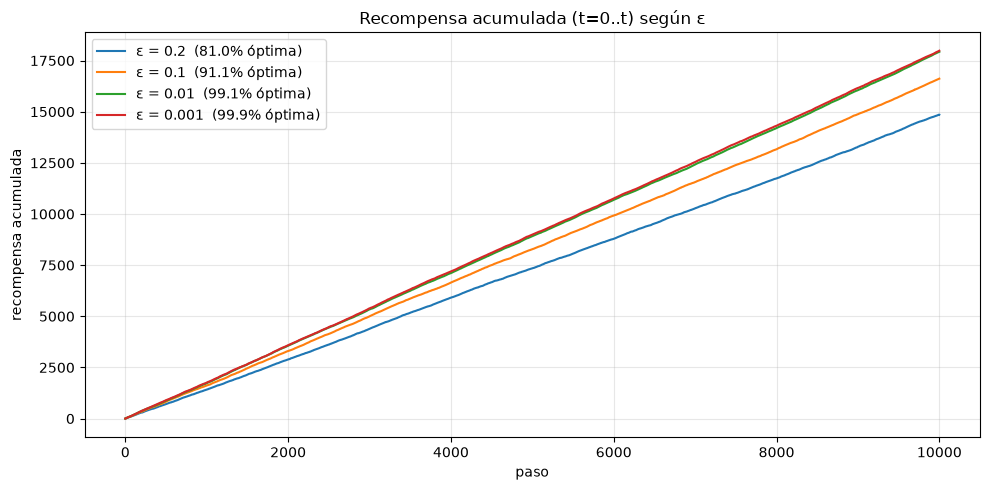

In [3]:
# Tabla resumen
print(f"{'eps':>7} | {'% óptima':>8} | {'recomp. media':>13} | acción greedy final")
print("-" * 58)
for epsilon, r in results.items():
    greedy = int(np.argmax(r["q"]))
    tag = "(óptima)" if greedy == OPTIMAL_ACTION else ""
    print(f"{epsilon:>7} | {r['pct_optimal']:>7.1f}% | {r['rewards'].mean():>13.3f} | {greedy} {tag}")

# Detalle: q y q_selected finales por brazo
print()
print("q y q_selected (counts) finales por brazo:")
print(f"{'brazo':>5} {'q*':>6} | " + " | ".join(f"{'eps=' + str(e):^14}" for e in epsilons))
print(f"{'':>5} {'':>6} | " + " | ".join(f"{'N / Q':^14}" for _ in epsilons))
for a in range(K):
    cells = " | ".join(
        f" {results[e]['counts'][a]:>4.0f} / {results[e]['q'][a]:>5.2f} " for e in epsilons
    )
    print(f"{a:>5} {Q_STAR[a]:>6.2f} | {cells}")

# Recompensa acumulada (t=0..t) por variante
plt.figure(figsize=(10, 5))
for epsilon, r in results.items():
    cumulative = np.cumsum(r["rewards"])
    plt.plot(cumulative, label=f"ε = {epsilon}  ({r['pct_optimal']:.1f}% óptima)")
plt.xlabel("paso")
plt.ylabel("recompensa acumulada")
plt.title("Recompensa acumulada (t=0..t) según ε")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()